# 07 — Well-level follow-up and model sensitivity

This notebook follows up on **Notebook 06: artifact diagnostics**.

In Notebook 06 found that:
- several morphology features have long tails and outliers;
- some features are strongly skewed;
- aggressive outlier removal plus log transformation reduced AUC and inducer recall;
- some drug-feature combinations show possible plate-level variation;
- several morphology features are highly correlated.

Therefore, this notebook tests more statistically careful follow-up analyses:
1. construct a well-level dataset;
2. repeat key EDA at the well level;
3. compute well-level effect sizes;
4. compare conservative preprocessing strategies without aggressive row deletion;
5. evaluate models using imbalance-aware metrics;
6. run threshold analysis;
7. test feature groups separately.

## 0. Setup and paths

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix
)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES = PROJECT_ROOT / "outputs" / "tables"
MODELS = PROJECT_ROOT / "outputs" / "models"

for p in [FIGURES, TABLES, MODELS]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)

PROJECT_ROOT: /Users/zhangyuxiang/Desktop/cell-aging-analysis
DATA_PROCESSED: /Users/zhangyuxiang/Desktop/cell-aging-analysis/data/processed


## 1. Load data, map compounds, and apply the existing filter

We reproduce the same starting point as earlier notebooks:
1. load `df_clean_wide.csv`;
2. map `Metadata_JCP2022` IDs to drug names;
3. apply the Emiliya-style filter.

In [2]:
df_raw = pd.read_csv(DATA_PROCESSED / "df_clean_wide.csv")

compound_mapping = pd.DataFrame({
    "Metadata_JCP2022": [
        "JCP2022_033924", "JCP2022_095995", "JCP2022_051785",
        "JCP2022_094347", "JCP2022_001418"
    ],
    "drug_name": ["DMSO", "hydroxyurea", "resveratrol", "etoposide", "palbociclib"],
    "category": ["control", "senescence_inducer", "seno_modulator", "senescence_inducer", "senescence_inducer"],
})

df = df_raw.merge(compound_mapping, on="Metadata_JCP2022", how="left")

filter_mask = (
    (df["Cells_AreaShape_FormFactor"] <= 1) &
    (df["Nuclei_AreaShape_FormFactor"] <= 1) &
    (df["Cells_AreaShape_EulerNumber"] == 1) &
    (df["Nuclei_AreaShape_EulerNumber"] == 1) &
    (df["NC_Ratio"] <= 1) &
    (df["NC_Ratio_Radius"] <= 1)
)

df = df.loc[filter_mask].copy()

print("Filtered shape:", df.shape)
print(df["drug_name"].value_counts())

Filtered shape: (102430, 28)
drug_name
DMSO           86012
hydroxyurea     6586
palbociclib     4708
resveratrol     3891
etoposide       1233
Name: count, dtype: int64


## 2. Define features and labels

Classification task:
- **Class 0:** DMSO control
- **Class 1:** known senescence inducers: hydroxyurea, palbociclib, etoposide

Resveratrol is kept as an exploratory holdout compound.

In [3]:
DRUG_ORDER = ["DMSO", "hydroxyurea", "palbociclib", "etoposide", "resveratrol"]
DRUG_COLORS = {
    "DMSO": "#5C5C5C",
    "hydroxyurea": "#D9A300",
    "palbociclib": "#FF7F0E",
    "etoposide": "#C51B7D",
    "resveratrol": "#D62728",
}

FEATURES = [
    "Cells_AreaShape_BoundingBoxArea",
    "Cells_AreaShape_Compactness",
    "Cells_AreaShape_Eccentricity",
    "Cells_AreaShape_FormFactor",
    "Cells_AreaShape_MeanRadius",
    "Cells_AreaShape_Perimeter",
    "Cells_AreaShape_Solidity",
    "Nuclei_AreaShape_BoundingBoxArea",
    "Nuclei_AreaShape_Compactness",
    "Nuclei_AreaShape_Eccentricity",
    "Nuclei_AreaShape_FormFactor",
    "Nuclei_AreaShape_MeanRadius",
    "Nuclei_AreaShape_Perimeter",
    "Nuclei_AreaShape_Solidity",
    "NC_Ratio",
    "NC_Ratio_Radius",
]

INDUCERS = ["hydroxyurea", "palbociclib", "etoposide"]
TRAIN_DRUGS = ["DMSO"] + INDUCERS

missing = [f for f in FEATURES if f not in df.columns]
assert not missing, f"Missing features: {missing}"

print("Number of features:", len(FEATURES))

Number of features: 16


## 3. Construct a well-level dataset

The major limitation of cell-level analysis is that cells from the same well are not independent. Here we aggregate to:

```text
one row = one well
features = within-well median feature values
```

In [4]:
well_df = (
    df.groupby(["Metadata_Plate", "Metadata_Well", "drug_name"], as_index=False)
      .agg(
          n_cells=("drug_name", "size"),
          **{f"{feat}_median": (feat, "median") for feat in FEATURES},
          **{f"{feat}_iqr": (feat, lambda x: x.quantile(0.75) - x.quantile(0.25)) for feat in FEATURES},
      )
)

well_features = [f"{feat}_median" for feat in FEATURES]

print("Cell-level shape:", df.shape)
print("Well-level shape:", well_df.shape)
display(well_df.head())

well_counts = (
    well_df.groupby("drug_name")
           .agg(
               n_wells=("Metadata_Well", "size"),
               total_cells=("n_cells", "sum"),
               median_cells_per_well=("n_cells", "median"),
               min_cells_per_well=("n_cells", "min"),
               max_cells_per_well=("n_cells", "max"),
           )
           .reindex(DRUG_ORDER)
)

display(well_counts)
well_counts.to_csv(TABLES / "well_counts_by_drug.csv")

Cell-level shape: (102430, 28)
Well-level shape: (49, 36)


,Metadata_Plate,Metadata_Well,drug_name,n_cells,Cells_AreaShape_BoundingBoxArea_median,Cells_AreaShape_Compactness_median,Cells_AreaShape_Eccentricity_median,Cells_AreaShape_FormFactor_median,Cells_AreaShape_MeanRadius_median,Cells_AreaShape_Perimeter_median,...,Cells_AreaShape_Solidity_iqr,Nuclei_AreaShape_BoundingBoxArea_iqr,Nuclei_AreaShape_Compactness_iqr,Nuclei_AreaShape_Eccentricity_iqr,Nuclei_AreaShape_FormFactor_iqr,Nuclei_AreaShape_MeanRadius_iqr,Nuclei_AreaShape_Perimeter_iqr,Nuclei_AreaShape_Solidity_iqr,NC_Ratio_iqr,NC_Ratio_Radius_iqr
0,CP1-SC1-01,C06,etoposide,650,6813.44625,3.552291,0.809326,0.281508,7.207047,391.861293,...,0.107397,216.74250,0.932721,0.158879,0.358007,0.950428,20.163530,0.136759,0.083960,0.231092
1,CP1-SC1-01,J12,resveratrol,2068,2804.97750,2.529510,0.809051,0.395333,5.087570,216.612359,...,0.100287,229.20625,0.929411,0.155002,0.365776,0.992798,21.315381,0.145964,0.147104,0.262012
2,CP1-SC1-18,A02,DMSO,2191,2499.51000,2.401543,0.809620,0.416399,4.977039,198.616270,...,0.096309,205.33500,0.266696,0.175189,0.159983,0.682150,17.080813,0.046281,0.127377,0.159005
3,CP1-SC1-18,A06,DMSO,2303,2407.40500,2.385463,0.805358,0.419206,4.904378,195.812359,...,0.096466,196.04000,0.265388,0.169719,0.161190,0.639643,16.196220,0.045828,0.139530,0.170301
4,CP1-SC1-18,A16,DMSO,2053,2669.77750,2.444230,0.818461,0.409127,5.039592,207.600785,...,0.106878,196.04000,0.294462,0.167379,0.172650,0.663323,16.250000,0.050262,0.133124,0.162257


,n_wells,total_cells,median_cells_per_well,min_cells_per_well,max_cells_per_well
drug_name,,,,,
DMSO,38,86012,2257.5,1905,2538
hydroxyurea,3,6586,2165.0,2160,2261
palbociclib,4,4708,1199.0,1017,1293
etoposide,2,1233,616.5,583,650
resveratrol,2,3891,1945.5,1823,2068


## 4. Well-level EDA by drug

Each point below is a **well median**, not an individual cell. This checks whether the cell-level patterns remain visible at the well level.

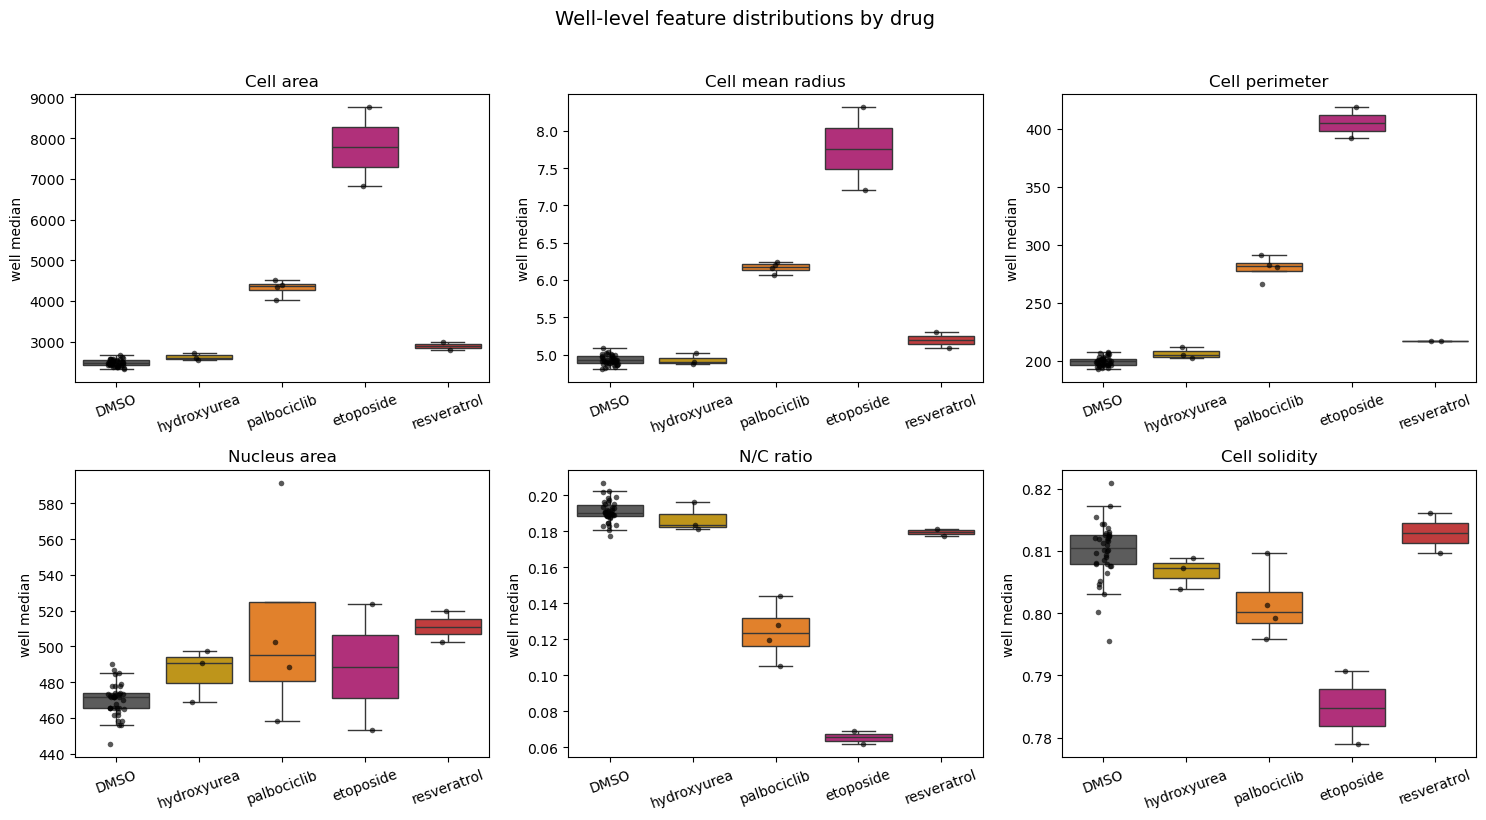

In [5]:
headline_features = [
    "Cells_AreaShape_BoundingBoxArea",
    "Cells_AreaShape_MeanRadius",
    "Cells_AreaShape_Perimeter",
    "Nuclei_AreaShape_BoundingBoxArea",
    "NC_Ratio",
    "Cells_AreaShape_Solidity",
]

headline_labels = {
    "Cells_AreaShape_BoundingBoxArea": "Cell area",
    "Cells_AreaShape_MeanRadius": "Cell mean radius",
    "Cells_AreaShape_Perimeter": "Cell perimeter",
    "Nuclei_AreaShape_BoundingBoxArea": "Nucleus area",
    "NC_Ratio": "N/C ratio",
    "Cells_AreaShape_Solidity": "Cell solidity",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, headline_features):
    y_col = f"{feat}_median"
    sns.boxplot(
        data=well_df, x="drug_name", y=y_col,
        order=DRUG_ORDER, palette=DRUG_COLORS,
        ax=ax, fliersize=0
    )
    sns.stripplot(
        data=well_df, x="drug_name", y=y_col,
        order=DRUG_ORDER, color="black", size=4,
        alpha=0.65, ax=ax
    )
    ax.set_title(headline_labels[feat])
    ax.set_xlabel("")
    ax.set_ylabel("well median")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Well-level feature distributions by drug", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES / "well_level_feature_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

Well-level analysis confirms that the strongest morphology differences are cell-size enlargement and reduced N/C ratio, especially for etoposide and palbociclib. This suggests that the main signals observed at the cell level are not purely caused by cell-level pseudo-replication.

## 5. Well-level effect sizes vs DMSO

We compute **Cohen's d** at the well level:
1. each treatment vs DMSO;
2. pooled known inducers vs DMSO.

This helps identify candidate morphology markers without relying on cell-level p-values.

In [6]:
def cohens_d(a, b):
    a = np.asarray(pd.Series(a).dropna(), dtype=float)
    b = np.asarray(pd.Series(b).dropna(), dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_var = ((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a) + len(b) - 2)
    pooled_sd = np.sqrt(pooled_var)
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan

dmso_wells = well_df[well_df["drug_name"] == "DMSO"]

effect_rows = []
for feat in FEATURES:
    y_col = f"{feat}_median"
    dmso_values = dmso_wells[y_col]
    for drug in [d for d in DRUG_ORDER if d != "DMSO"]:
        drug_values = well_df.loc[well_df["drug_name"] == drug, y_col]
        d_value = cohens_d(drug_values, dmso_values)
        effect_rows.append({
            "comparison": f"{drug} vs DMSO",
            "treatment": drug,
            "feature": feat,
            "cohens_d": d_value,
            "abs_d": abs(d_value) if pd.notna(d_value) else np.nan,
            "n_treatment_wells": len(drug_values),
            "n_dmso_wells": len(dmso_values),
        })

effect_df = pd.DataFrame(effect_rows).sort_values("abs_d", ascending=False)
effect_df.to_csv(TABLES / "well_level_treatment_vs_dmso_effect_sizes.csv", index=False)
display(effect_df.head(20).round(3))

,comparison,treatment,feature,cohens_d,abs_d,n_treatment_wells,n_dmso_wells
22,etoposide vs DMSO,etoposide,Cells_AreaShape_Perimeter,41.559,41.559,2,38
62,etoposide vs DMSO,etoposide,NC_Ratio_Radius,-29.894,29.894,2,38
2,etoposide vs DMSO,etoposide,Cells_AreaShape_BoundingBoxArea,22.380,22.380,2,38
58,etoposide vs DMSO,etoposide,NC_Ratio,-20.540,20.540,2,38
18,etoposide vs DMSO,etoposide,Cells_AreaShape_MeanRadius,19.947,19.947,2,38
1,palbociclib vs DMSO,palbociclib,Cells_AreaShape_BoundingBoxArea,19.060,19.060,4,38
17,palbociclib vs DMSO,palbociclib,Cells_AreaShape_MeanRadius,18.921,18.921,4,38
21,palbociclib vs DMSO,palbociclib,Cells_AreaShape_Perimeter,17.095,17.095,4,38
6,etoposide vs DMSO,etoposide,Cells_AreaShape_Compactness,13.620,13.620,2,38
14,etoposide vs DMSO,etoposide,Cells_AreaShape_FormFactor,-11.670,11.670,2,38


In [9]:
# Pooled known inducer vs DMSO
inducer_wells = well_df[well_df["drug_name"].isin(INDUCERS)]

pooled_rows = []
for feat in FEATURES:
    y_col = f"{feat}_median"
    d_value = cohens_d(inducer_wells[y_col], dmso_wells[y_col])
    pooled_rows.append({
        "feature": feat,
        "cohens_d_inducer_vs_dmso": d_value,
        "abs_d": abs(d_value) if pd.notna(d_value) else np.nan,
        "n_inducer_wells": len(inducer_wells),
        "n_dmso_wells": len(dmso_wells),
    })

pooled_effect_df = (
    pd.DataFrame(pooled_rows)
      .sort_values("abs_d", ascending=False)
      .drop(columns="abs_d")
)

pooled_effect_df.to_csv(TABLES / "well_level_pooled_inducer_vs_dmso_effect_sizes.csv", index=False)
display(pooled_effect_df.round(3))

,feature,cohens_d_inducer_vs_dmso,n_inducer_wells,n_dmso_wells
14,NC_Ratio,-2.766,9,38
3,Cells_AreaShape_FormFactor,-2.613,9,38
5,Cells_AreaShape_Perimeter,2.544,9,38
4,Cells_AreaShape_MeanRadius,2.453,9,38
15,NC_Ratio_Radius,-2.449,9,38
1,Cells_AreaShape_Compactness,2.386,9,38
0,Cells_AreaShape_BoundingBoxArea,2.335,9,38
6,Cells_AreaShape_Solidity,-1.765,9,38
12,Nuclei_AreaShape_Perimeter,1.674,9,38
2,Cells_AreaShape_Eccentricity,1.527,9,38


## 6. Conservative preprocessing sensitivity tests

Notebook 06 showed that aggressive row deletion reduced AUC and inducer recall. Therefore, here we avoid deleting cells and compare gentler approaches:

1. raw filtered features;
2. log-transform selected size features only;
3. winsorization, which clips extreme values instead of deleting rows;
4. winsorization plus log-transforming size features.

In [7]:
SIZE_FEATURES = [
    "Cells_AreaShape_BoundingBoxArea",
    "Cells_AreaShape_MeanRadius",
    "Cells_AreaShape_Perimeter",
    "Nuclei_AreaShape_BoundingBoxArea",
    "Nuclei_AreaShape_MeanRadius",
    "Nuclei_AreaShape_Perimeter",
]

def make_preprocessed_df(data, strategy):
    out = data.copy()
    if strategy in ["winsorize", "winsorize_log_size"]:
        for feat in FEATURES:
            lo, hi = out[feat].quantile([0.01, 0.99])
            out[feat] = out[feat].clip(lo, hi)
    if strategy in ["log_size", "winsorize_log_size"]:
        for feat in SIZE_FEATURES:
            out[feat] = np.log1p(out[feat])
    return out

preprocessing_strategies = ["raw", "log_size", "winsorize", "winsorize_log_size"]

for s in preprocessing_strategies:
    tmp = make_preprocessed_df(df, s)
    print(s, tmp.shape)

raw (102430, 28)
log_size (102430, 28)
winsorize (102430, 28)
winsorize_log_size (102430, 28)


## 7. Cell-level Random Forest with imbalance-aware metrics

We compare preprocessing strategies using GroupKFold by well. Because DMSO is the majority class, we evaluate more than raw accuracy:

- balanced accuracy;
- precision;
- recall;
- F1;
- ROC-AUC;
- PR-AUC.

In [10]:
def evaluate_cell_level_rf(data, feature_cols, strategy_name, n_splits=5, threshold=0.5):
    d = data[data["drug_name"].isin(TRAIN_DRUGS)].copy()
    d["label"] = d["drug_name"].isin(INDUCERS).astype(int)
    d["well_id"] = d["Metadata_Plate"] + "_" + d["Metadata_Well"]

    X = d[feature_cols].values
    y = d["label"].values
    groups = d["well_id"].values

    n_splits = min(n_splits, d["well_id"].nunique())
    gkf = GroupKFold(n_splits=n_splits)

    fold_rows = []
    all_y_true, all_y_prob, all_y_pred = [], [], []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        clf = RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42 + fold,
            n_jobs=-1,
        )
        clf.fit(X[train_idx], y[train_idx])
        prob = clf.predict_proba(X[test_idx])[:, 1]
        pred = (prob >= threshold).astype(int)
        y_test = y[test_idx]

        all_y_true.append(y_test)
        all_y_prob.append(prob)
        all_y_pred.append(pred)

        fold_rows.append({
            "strategy": strategy_name,
            "fold": fold,
            "n_test": len(test_idx),
            "positive_rate_test": y_test.mean(),
            "accuracy": accuracy_score(y_test, pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, prob) if len(np.unique(y_test)) == 2 else np.nan,
            "pr_auc": average_precision_score(y_test, prob),
        })

    pooled = {
        "strategy": strategy_name,
        "y_true": np.concatenate(all_y_true),
        "y_prob": np.concatenate(all_y_prob),
        "y_pred": np.concatenate(all_y_pred),
    }

    return pd.DataFrame(fold_rows), pooled

cell_metric_frames = []
cell_pooled_predictions = {}

for strategy in preprocessing_strategies:
    d_prep = make_preprocessed_df(df, strategy)
    metrics_df, pooled = evaluate_cell_level_rf(d_prep, FEATURES, strategy)
    cell_metric_frames.append(metrics_df)
    cell_pooled_predictions[strategy] = pooled

cell_metrics = pd.concat(cell_metric_frames, ignore_index=True)
cell_metrics.to_csv(TABLES / "cell_level_preprocessing_metrics_by_fold.csv", index=False)
display(cell_metrics.round(3))

,strategy,fold,n_test,positive_rate_test,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,raw,0,20003,0.108,0.880,0.496,0.055,0.007,0.012,0.526,0.112
1,raw,1,19408,0.065,0.940,0.594,0.600,0.197,0.296,0.770,0.306
2,raw,2,19839,0.193,0.835,0.583,0.878,0.171,0.287,0.698,0.493
3,raw,3,19882,0.200,0.836,0.602,0.876,0.211,0.341,0.680,0.501
4,raw,4,19407,0.067,0.943,0.618,0.701,0.244,0.362,0.784,0.395
5,log_size,0,20003,0.108,0.880,0.496,0.055,0.007,0.012,0.527,0.112
6,log_size,1,19408,0.065,0.939,0.593,0.592,0.194,0.293,0.770,0.306
7,log_size,2,19839,0.193,0.836,0.583,0.879,0.172,0.288,0.698,0.493
8,log_size,3,19882,0.200,0.836,0.602,0.875,0.211,0.341,0.680,0.501
9,log_size,4,19407,0.067,0.943,0.619,0.701,0.245,0.363,0.784,0.396


In [11]:
cell_summary = (
    cell_metrics
    .groupby("strategy")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        sd_roc_auc=("roc_auc", "std"),
        sd_recall=("recall", "std"),
    )
    .sort_values("mean_pr_auc", ascending=False)
)

cell_summary.to_csv(TABLES / "cell_level_preprocessing_metrics_summary.csv")
display(cell_summary.round(3))

,mean_accuracy,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_roc_auc,mean_pr_auc,sd_roc_auc,sd_recall
strategy,,,,,,,,,
log_size,0.887,0.579,0.621,0.166,0.259,0.692,0.361,0.103,0.093
raw,0.887,0.579,0.622,0.166,0.260,0.692,0.361,0.103,0.093
winsorize,0.887,0.579,0.626,0.167,0.261,0.690,0.361,0.103,0.092
winsorize_log_size,0.887,0.579,0.625,0.166,0.261,0.690,0.361,0.103,0.093


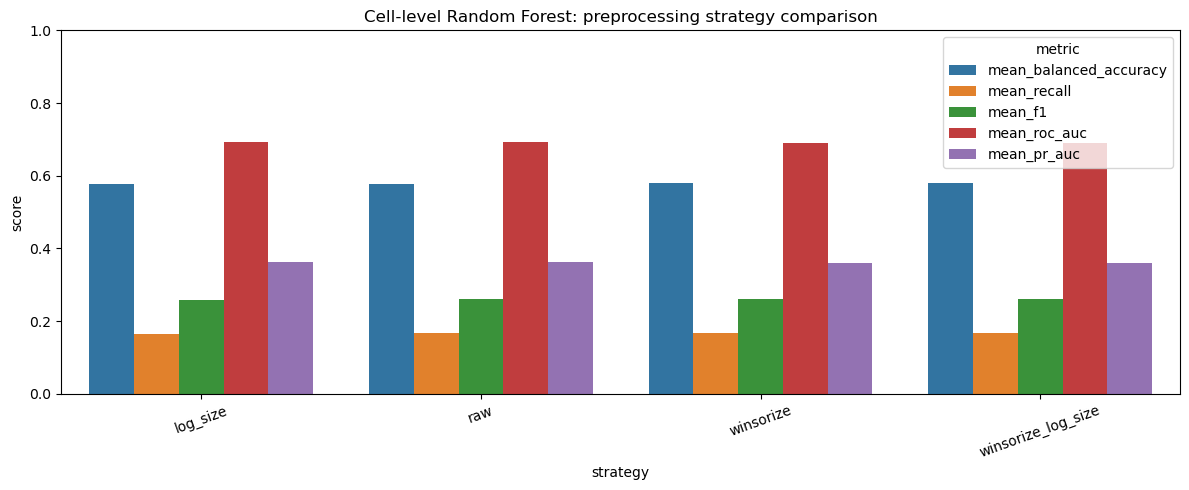

In [12]:
plot_metrics = ["mean_balanced_accuracy", "mean_recall", "mean_f1", "mean_roc_auc", "mean_pr_auc"]
plot_df = cell_summary[plot_metrics].reset_index().melt(
    id_vars="strategy",
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="strategy", y="score", hue="metric")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.title("Cell-level Random Forest: preprocessing strategy comparison")
plt.tight_layout()
plt.savefig(FIGURES / "cell_level_preprocessing_strategy_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

Conservative preprocessing strategies produced very similar model performance to the raw filtered features. This suggests that skewness and moderate extreme values are not the main limiting factor for the current classifier.

## 8. Threshold analysis

The default probability threshold of 0.5 may be too conservative for the inducer class. Here we examine how precision, recall, F1, and balanced accuracy change across thresholds.

In [13]:
def threshold_table(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.55, 0.05)
    rows = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "accuracy": accuracy_score(y_true, pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

raw_pooled = cell_pooled_predictions["raw"]
threshold_df = threshold_table(raw_pooled["y_true"], raw_pooled["y_prob"])
threshold_df.to_csv(TABLES / "threshold_analysis_raw_cell_level.csv", index=False)
display(threshold_df.round(3))

,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.05,0.271,0.528,0.135,0.873,0.233
1,0.10,0.586,0.598,0.176,0.615,0.274
2,0.15,0.775,0.626,0.263,0.427,0.326
3,0.20,0.841,0.628,0.365,0.342,0.354
4,0.25,0.868,0.620,0.470,0.288,0.357
5,0.30,0.880,0.611,0.558,0.252,0.347
6,0.35,0.884,0.602,0.615,0.224,0.328
7,0.40,0.886,0.595,0.663,0.205,0.313
8,0.45,0.886,0.586,0.699,0.184,0.292
9,0.50,0.886,0.578,0.730,0.166,0.270


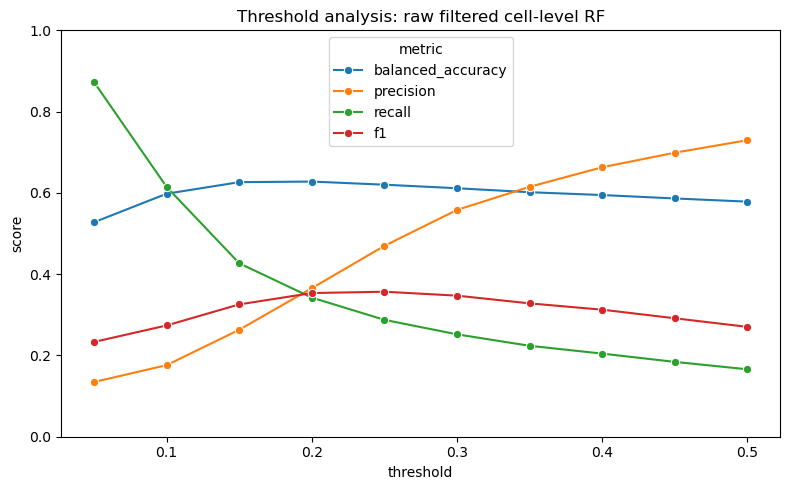

In [14]:
threshold_long = threshold_df.melt(
    id_vars="threshold",
    value_vars=["balanced_accuracy", "precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(8, 5))
sns.lineplot(data=threshold_long, x="threshold", y="score", hue="metric", marker="o")
plt.ylim(0, 1)
plt.title("Threshold analysis: raw filtered cell-level RF")
plt.tight_layout()
plt.savefig(FIGURES / "threshold_analysis_raw_cell_level.png", dpi=180, bbox_inches="tight")
plt.show()

The default 0.5 threshold is too conservative for detecting inducer-like cells. Lowering the threshold substantially increases inducer recall, although at the cost of lower precision. A threshold around 0.20–0.25 appears to give a better recall–precision trade-off than 0.5.

## 9. Well-level classifier

We now evaluate models on the well-level dataset. This is a smaller dataset, so results will be noisier, but it is statistically more honest.

In [15]:
def evaluate_well_level_models(well_data, feature_cols, n_splits=5, threshold=0.5):
    d = well_data[well_data["drug_name"].isin(TRAIN_DRUGS)].copy()
    d["label"] = d["drug_name"].isin(INDUCERS).astype(int)

    X = d[feature_cols].values
    y = d["label"].values

    min_class_count = pd.Series(y).value_counts().min()
    n_splits = int(min(n_splits, min_class_count))
    if n_splits < 2:
        raise ValueError("Not enough wells per class for cross-validation.")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    models = {
        "logistic_regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42)),
        ]),
        "random_forest": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    }

    rows = []
    for model_name, model in models.items():
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            model.fit(X[train_idx], y[train_idx])
            prob = model.predict_proba(X[test_idx])[:, 1]
            pred = (prob >= threshold).astype(int)
            y_test = y[test_idx]

            rows.append({
                "model": model_name,
                "fold": fold,
                "n_test_wells": len(test_idx),
                "positive_rate_test": y_test.mean(),
                "accuracy": accuracy_score(y_test, pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, pred),
                "precision": precision_score(y_test, pred, zero_division=0),
                "recall": recall_score(y_test, pred, zero_division=0),
                "f1": f1_score(y_test, pred, zero_division=0),
                "roc_auc": roc_auc_score(y_test, prob) if len(np.unique(y_test)) == 2 else np.nan,
                "pr_auc": average_precision_score(y_test, prob),
            })

    return pd.DataFrame(rows)

well_model_metrics = evaluate_well_level_models(well_df, well_features)
well_model_metrics.to_csv(TABLES / "well_level_model_metrics_by_fold.csv", index=False)
display(well_model_metrics.round(3))

,model,fold,n_test_wells,positive_rate_test,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,logistic_regression,0,10,0.200,0.900,0.750,1.000,0.5,0.667,1.000,1.000
1,logistic_regression,1,10,0.200,0.900,0.750,1.000,0.5,0.667,1.000,1.000
2,logistic_regression,2,9,0.222,1.000,1.000,1.000,1.0,1.000,1.000,1.000
3,logistic_regression,3,9,0.222,1.000,1.000,1.000,1.0,1.000,1.000,1.000
4,logistic_regression,4,9,0.111,0.778,0.875,0.333,1.0,0.500,1.000,1.000
5,random_forest,0,10,0.200,0.900,0.750,1.000,0.5,0.667,0.938,0.833
6,random_forest,1,10,0.200,0.900,0.750,1.000,0.5,0.667,0.938,0.833
7,random_forest,2,9,0.222,1.000,1.000,1.000,1.0,1.000,1.000,1.000
8,random_forest,3,9,0.222,0.889,0.750,1.000,0.5,0.667,1.000,1.000
9,random_forest,4,9,0.111,0.889,0.938,0.500,1.0,0.667,1.000,1.000


In [16]:
well_model_summary = (
    well_model_metrics
    .groupby("model")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        sd_roc_auc=("roc_auc", "std"),
    )
    .sort_values("mean_pr_auc", ascending=False)
)

well_model_summary.to_csv(TABLES / "well_level_model_metrics_summary.csv")
display(well_model_summary.round(3))

,mean_accuracy,mean_balanced_accuracy,mean_precision,mean_recall,mean_f1,mean_roc_auc,mean_pr_auc,sd_roc_auc
model,,,,,,,,
logistic_regression,0.916,0.875,0.867,0.8,0.767,1.000,1.000,0.000
random_forest,0.916,0.838,0.900,0.7,0.733,0.975,0.933,0.034


## 10. Feature group ablation

Because many morphology features are correlated, individual feature importance can be hard to interpret. Here we test feature groups directly.

In [17]:
feature_groups = {
    "cell_size": [
        "Cells_AreaShape_BoundingBoxArea",
        "Cells_AreaShape_MeanRadius",
        "Cells_AreaShape_Perimeter",
    ],
    "cell_shape": [
        "Cells_AreaShape_Compactness",
        "Cells_AreaShape_Eccentricity",
        "Cells_AreaShape_FormFactor",
        "Cells_AreaShape_Solidity",
    ],
    "nucleus_size": [
        "Nuclei_AreaShape_BoundingBoxArea",
        "Nuclei_AreaShape_MeanRadius",
        "Nuclei_AreaShape_Perimeter",
    ],
    "nucleus_shape": [
        "Nuclei_AreaShape_Compactness",
        "Nuclei_AreaShape_Eccentricity",
        "Nuclei_AreaShape_FormFactor",
        "Nuclei_AreaShape_Solidity",
    ],
    "nc_ratio": [
        "NC_Ratio",
        "NC_Ratio_Radius",
    ],
}

feature_sets = {"all_features": FEATURES.copy()}
feature_sets.update(feature_groups)
for group_name, group_feats in feature_groups.items():
    feature_sets[f"all_except_{group_name}"] = [f for f in FEATURES if f not in group_feats]

for name, feats in feature_sets.items():
    print(f"{name}: {len(feats)} features")

all_features: 16 features
cell_size: 3 features
cell_shape: 4 features
nucleus_size: 3 features
nucleus_shape: 4 features
nc_ratio: 2 features
all_except_cell_size: 13 features
all_except_cell_shape: 12 features
all_except_nucleus_size: 13 features
all_except_nucleus_shape: 12 features
all_except_nc_ratio: 14 features


In [18]:
ablation_frames = []
for set_name, feats in feature_sets.items():
    metrics_df, _ = evaluate_cell_level_rf(df, feats, set_name)
    ablation_frames.append(metrics_df)

ablation_metrics = pd.concat(ablation_frames, ignore_index=True)
ablation_metrics.to_csv(TABLES / "feature_group_ablation_by_fold.csv", index=False)

ablation_summary = (
    ablation_metrics
    .groupby("strategy")
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
    )
    .sort_values("mean_pr_auc", ascending=False)
)

ablation_summary.to_csv(TABLES / "feature_group_ablation_summary.csv")
display(ablation_summary.round(3))

,mean_balanced_accuracy,mean_recall,mean_f1,mean_roc_auc,mean_pr_auc
strategy,,,,,
all_except_nucleus_size,0.576,0.161,0.253,0.689,0.362
all_except_nc_ratio,0.575,0.159,0.251,0.692,0.362
all_features,0.579,0.166,0.260,0.692,0.361
all_except_cell_size,0.574,0.157,0.247,0.691,0.357
all_except_nucleus_shape,0.579,0.167,0.260,0.685,0.357
all_except_cell_shape,0.580,0.170,0.264,0.684,0.355
cell_size,0.555,0.122,0.193,0.642,0.274
nc_ratio,0.557,0.138,0.199,0.607,0.250
cell_shape,0.512,0.034,0.058,0.573,0.173


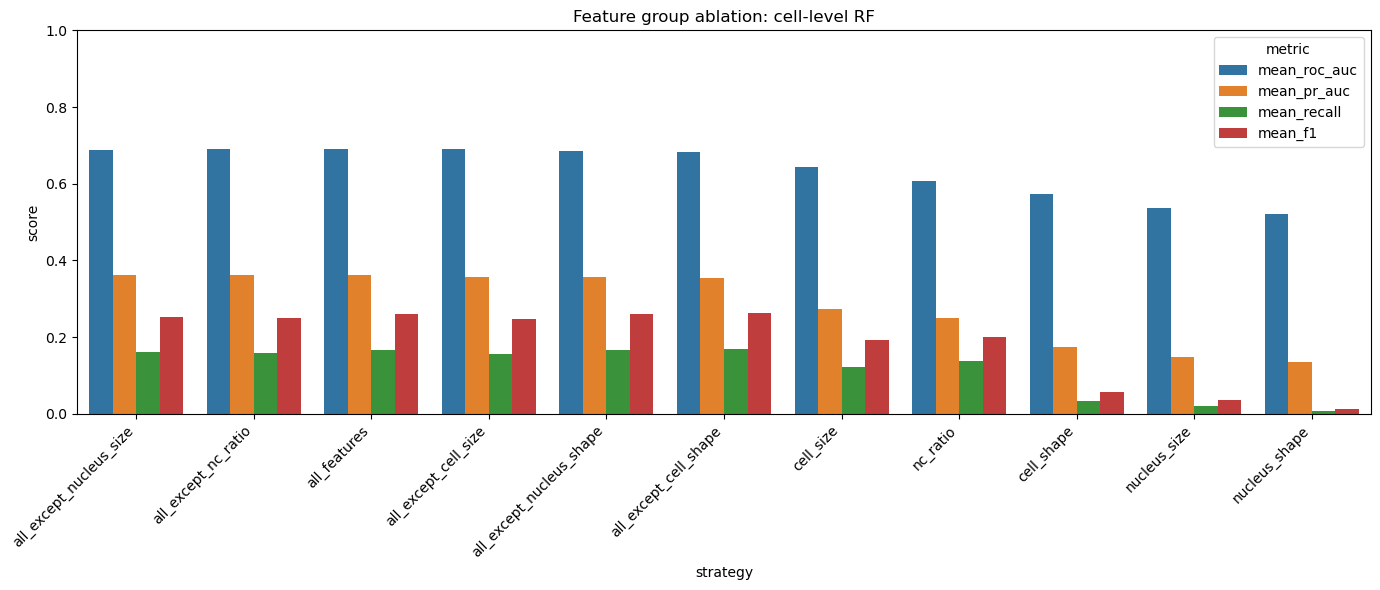

In [19]:
ablation_plot = ablation_summary.reset_index().melt(
    id_vars="strategy",
    value_vars=["mean_roc_auc", "mean_pr_auc", "mean_recall", "mean_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(14, 6))
sns.barplot(data=ablation_plot, x="strategy", y="score", hue="metric")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.title("Feature group ablation: cell-level RF")
plt.tight_layout()
plt.savefig(FIGURES / "feature_group_ablation.png", dpi=180, bbox_inches="tight")
plt.show()

Feature group ablation suggests that the strongest individual signal comes from cell-size features and N/C ratio, while nucleus-only feature groups are weaker. However, removing any single feature group from the full model does not strongly reduce performance, indicating redundancy among morphology features.

## 11. Resveratrol exploratory scoring

Resveratrol is not included in binary training. A final Random Forest trained on DMSO + known inducers is used to score resveratrol cells.

This is exploratory and should not be treated as a definitive biological conclusion.

In [20]:
train_df = df[df["drug_name"].isin(TRAIN_DRUGS)].copy()
train_df["label"] = train_df["drug_name"].isin(INDUCERS).astype(int)

X_train = train_df[FEATURES].values
y_train = train_df["label"].values

final_rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
final_rf.fit(X_train, y_train)

scored_df = df.copy()
scored_df["inducer_probability"] = final_rf.predict_proba(scored_df[FEATURES].values)[:, 1]

score_summary = (
    scored_df.groupby("drug_name")["inducer_probability"]
             .agg(["count", "mean", "median", "std"])
             .reindex(DRUG_ORDER)
)

display(score_summary.round(3))
score_summary.to_csv(TABLES / "rf_inducer_probability_by_drug.csv")

,count,mean,median,std
drug_name,,,,
DMSO,86012,0.039,0.032,0.032
hydroxyurea,6586,0.675,0.670,0.040
palbociclib,4708,0.774,0.744,0.105
etoposide,1233,0.854,0.892,0.115
resveratrol,3891,0.200,0.136,0.182


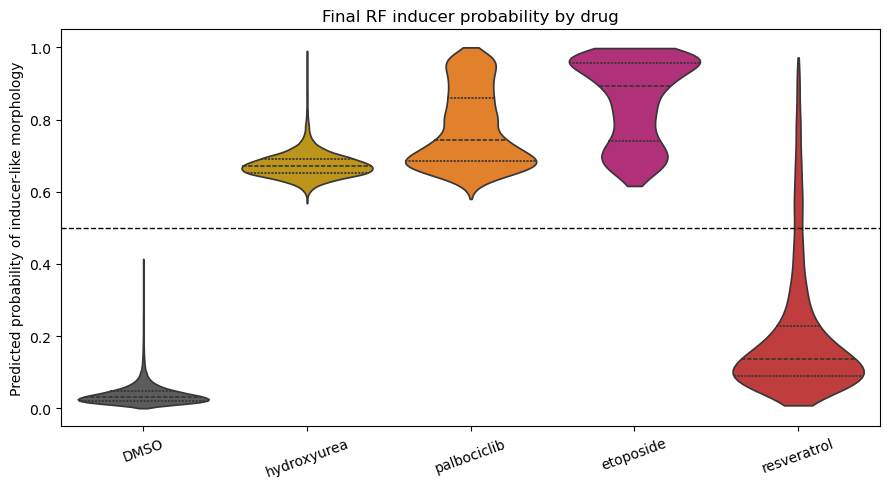

In [21]:
plt.figure(figsize=(9, 5))
sns.violinplot(
    data=scored_df,
    x="drug_name",
    y="inducer_probability",
    order=DRUG_ORDER,
    palette=DRUG_COLORS,
    cut=0,
    inner="quartile",
)
plt.axhline(0.5, linestyle="--", color="black", linewidth=1)
plt.xticks(rotation=20)
plt.title("Final RF inducer probability by drug")
plt.xlabel("")
plt.ylabel("Predicted probability of inducer-like morphology")
plt.tight_layout()
plt.savefig(FIGURES / "resveratrol_holdout_probability_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

Resveratrol is mostly scored closer to DMSO than to known inducers, but its probability distribution has a long upper tail. This suggests that resveratrol does not strongly resemble the pooled inducer class overall, although a subset of cells may show inducer-like morphology.

## 12. Summary and next steps

### What this notebook did

1. **Moved analysis to the well level.**  
   A well-level dataset was constructed using median morphology features per well. This helps address pseudo-replication from treating thousands of cells as independent observations.

2. **Repeated key EDA at the well level.**  
   Well-level boxplots check whether the major morphology differences remain visible when each well contributes one observation.

3. **Computed well-level effect sizes.**  
   Cohen's d was used to rank features for treatment-vs-DMSO and pooled-inducer-vs-DMSO comparisons.

4. **Compared conservative preprocessing strategies.**  
   Instead of deleting extreme cells, this notebook compares raw filtered features, log-transformed size features, winsorized features, and winsorized plus log-transformed features.

5. **Used imbalance-aware model evaluation.**  
   Model evaluation includes balanced accuracy, recall, F1, ROC-AUC, and PR-AUC, rather than relying on raw accuracy.

6. **Performed threshold analysis.**  
   This checks whether the default 0.5 threshold is too conservative for inducer detection.

7. **Ran feature group ablation.**  
   Feature groups were tested directly to determine whether the signal mainly comes from cell size, nucleus size, shape, or N/C ratio.

8. **Revisited resveratrol as an exploratory holdout.**  
   Resveratrol was scored using a final Random Forest trained on DMSO and known inducers.

### Personal Notes:
The main morphology signal still exists at the well-level; preprocessing itself is not the main bottleneck; the threshold can be set at around 0.2; cell size and N/C ratio are the main predictive signals; resveratrol is generally closer to DMSO, but there is some heterogeneity.

### Next steps

1. Use well-level effect sizes to summarize candidate markers for the weekly report.
2. Use imbalance-aware metrics and threshold analysis when discussing classifier performance.
3. Avoid aggressive row deletion unless supported by image-level or well-level quality control.
4. Compare whether cell-size and N/C-ratio signals replicate in additional datasets.
5. Next week, start exploring additional Cell Painting / JUMP-related datasets by checking feature overlap, compound overlap, preprocessing compatibility, and whether the same morphology signals appear.